In [101]:
import numpy as np
import pandas as pd
import scipy.io
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import itertools

from pathlib import Path

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Load data

In [40]:
DATA_DIR = Path("./data")

X = scipy.io.mmread(DATA_DIR / "matrix.mtx").tocsr()   # genes x cells
genes = pd.read_csv(DATA_DIR / "genes.tsv", sep="\t", header=None)
barcodes = pd.read_csv(DATA_DIR / "barcodes.tsv", sep="\t", header=None)

gene_names = genes.iloc[:, 1].astype(str).values if genes.shape[1] > 1 else genes.iloc[:, 0].astype(str).values
cell_names = barcodes.iloc[:, 0].astype(str).values

# convert to cells x genes
X = X.T.tocsr()

print("cells x genes:", X.shape)

cells x genes: (2700, 32738)


# Calculate number of PCs for x% explained variance 

In [85]:
var_path = "/Users/yulunc125/cmu/26_spring/ML/project/data/PCA_variance.csv"
var_df = pd.read_csv(var_path)

In [86]:
def get_pcs(df, threshold=0.8, col_name="explained_variance_ratio"):
    cumulative = df[col_name].cumsum()
    pcs_needed = np.argmax(cumulative >= threshold) + 1

    if cumulative.iloc[-1] < threshold:
        return None
    
    return pcs_needed

In [87]:
pcs_70 = get_pcs(var_df, threshold=0.7)
print("# PCs for 70% explained variance:", pcs_70)
pcs_75 = get_pcs(var_df, threshold=0.75)
print("# PCs for 75% explained variance:", pcs_75)
pcs_80 = get_pcs(var_df, threshold=0.8)
print("# PCs for 80% explained variance:", pcs_80)
pcs_85 = get_pcs(var_df, threshold=0.85)
print("# PCs for 85% explained variance:", pcs_85)
pcs_90 = get_pcs(var_df, threshold=0.9)
print("# PCs for 90% explained variance:", pcs_90)
pcs_95 = get_pcs(var_df, threshold=0.95)
print("# PCs for 95% explained variance:", pcs_95)


# PCs for 70% explained variance: 608
# PCs for 75% explained variance: 695
# PCs for 80% explained variance: 796
# PCs for 85% explained variance: 918
# PCs for 90% explained variance: 1074
# PCs for 95% explained variance: 1301


1074


Text(0.5, 1.0, 'Cummulative curve of explained variance ratio')

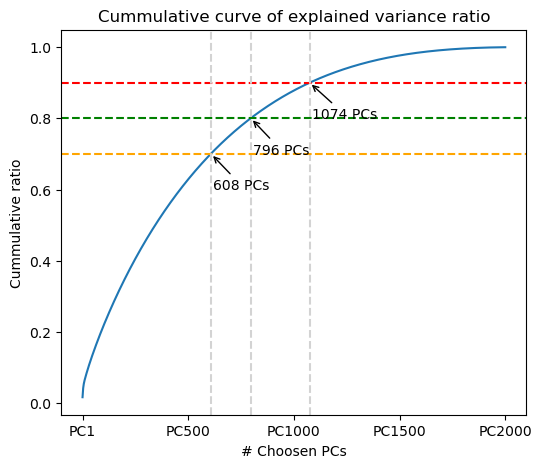

In [81]:
cum_var = var_df["explained_variance_ratio"].cumsum()
print(np.argmax(cum_var >= 0.9) + 1)
num_90 = np.argmax(cum_var >= 0.9) + 1

plt.figure(figsize=(6, 5))
plt.plot(cum_var)
plt.xticks(["PC1", "PC500", "PC1000", "PC1500", "PC2000"])

plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=1074, color='lightgray', linestyle='--')

plt.axhline(y=0.8, color='green', linestyle='--')
plt.axvline(x=796, color='lightgray', linestyle='--')

plt.axhline(y=0.7, color='orange', linestyle='--')
plt.axvline(x=608, color='lightgray', linestyle='--')

plt.annotate(
    "1074 PCs",
    xy=(1074, 0.9),
    xytext=(1085, 0.8),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "796 PCs",
    xy=(796, 0.8),
    xytext=(805, 0.7),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "608 PCs",
    xy=(608, 0.7),
    xytext=(618, 0.6),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("# Choosen PCs")
plt.ylabel("Cummulative ratio")
plt.title("Cummulative curve of explained variance ratio")

In [88]:
emb_path = "/Users/yulunc125/cmu/26_spring/ML/project/data/PCAembedding.csv"
emb_df = pd.read_csv(emb_path, index_col=0)
emb_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC1341,PC1342,PC1343,PC1344,PC1345,PC1346,PC1347,PC1348,PC1349,PC1350
AAACATACAACCAC-1,-0.964063,2.558047,0.814929,2.842345,0.034208,0.041280,-0.016642,0.206203,0.052288,0.017649,...,0.687182,0.251016,0.812514,-0.690349,-0.767867,-0.476919,0.612732,-0.088939,0.160042,-0.247618
AAACATTGAGCTAC-1,-0.131150,1.332594,-8.208489,-4.366259,-1.040107,0.234649,0.142871,0.234902,-0.772652,0.495442,...,-0.888960,-0.221976,1.114021,0.181165,-0.272433,-0.792308,-0.593261,-0.007943,-0.074881,-0.799824
AAACATTGATCAGC-1,-0.690134,1.392094,-0.401498,2.889005,0.093899,0.051382,-0.064045,-0.487006,0.141959,-0.180359,...,0.194215,-0.303410,0.370223,-0.061666,-0.786826,0.168263,0.438420,0.477303,-0.232072,-0.124308
AAACCGTGCTTCCG-1,0.092562,-6.223090,2.134852,-1.742413,-1.207215,-0.360461,-0.102218,0.305422,0.014068,0.526648,...,0.587114,0.285151,-0.026834,0.837595,0.518630,-0.063869,-0.027948,0.334997,0.226869,0.154326
AAACCGTGTATGCG-1,-1.149333,7.079701,7.538548,-5.999182,-0.088866,0.212916,0.776521,0.039928,-0.226721,0.244121,...,-0.728467,-0.725540,-0.296182,0.411625,0.892419,-0.079493,-0.617394,-0.121413,0.015186,0.265611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,0.264672,-7.821285,2.106891,-2.687673,0.539881,-0.630611,0.573680,-1.570901,-1.039774,1.045736,...,0.031077,0.685278,-0.583493,0.409689,0.718809,-0.659177,0.463038,-0.026885,-0.004418,0.018299
TTTCTACTGAGGCA-1,1.466533,1.199009,-6.186806,-2.531331,1.033896,0.031819,-2.415936,0.872648,-0.226083,-1.764959,...,0.434823,0.290314,0.535224,-0.330501,0.014816,-1.493778,-0.153968,0.167263,0.564960,-1.797764
TTTCTACTTCCTCG-1,-1.035874,1.002496,-9.460107,-4.332999,-0.672419,-0.159739,0.303746,0.196134,0.374482,0.300144,...,-0.227085,0.688856,0.828617,0.033527,-0.220327,-0.250621,0.151405,0.336149,0.347118,0.522200
TTTGCATGAGAGGC-1,-1.138572,2.364083,-7.121927,-3.211790,0.448172,-0.557496,0.346059,-0.446345,-0.375405,-0.169349,...,0.274259,-0.101819,-0.061809,0.305555,0.224961,-0.471336,-0.748625,-0.069202,0.001913,-0.754179


In [89]:
adata = sc.datasets.pbmc3k_processed()

# Align cells present in both
cell_index = emb_df.index
common = cell_index.intersection(adata.obs_names)
print(f"Cells in PCA: {len(cell_index)}, in adata: {adata.n_obs}, in common: {len(common)}")

X_pca = emb_df.loc[common]
adata = adata[common]
true_labels = adata.obs["louvain"].values

print(f"Final shape: {X_pca.shape[0]}")
print(f"Cell types ({adata.obs['louvain'].nunique()}): {list(adata.obs['louvain'].cat.categories)}")

Cells in PCA: 2700, in adata: 2638, in common: 2638
Final shape: 2638
Cell types (8): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']


In [90]:
true_labels

['CD4 T cells', 'B cells', 'CD4 T cells', 'CD14+ Monocytes', 'NK cells', ..., 'CD14+ Monocytes', 'B cells', 'B cells', 'B cells', 'CD4 T cells']
Length: 2638
Categories (8, object): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']

# K-means

In [10]:
def KMeansClustering(x, means):
    
    n_sample, n_feature = x.shape
    K = means.shape[0]
    
    new_clusters = np.zeros([n_sample,], dtype=int)
    new_means = means.copy()
    iter_objs = []

    def assign_clusters(x, means):
        # x: (n_sample, 1, n_feature)
        # means: (1, K, n_feature)
        # distances: (n_sample, K)
        # clusters: (n_sample,)
        x = x[:, None, :]
        means = means[None, :, :]

        #calculate distance based on samples (features)
        distances = ((x-means) ** 2).sum(axis=2) # shape: (gene_num, cluster_num)
        clusters = np.argmin(distances, axis=1) # shape: (gene_num)

        return clusters, distances
        
    def update_means(x, clusters, old_means):
        means = old_means.copy()

        for k in range(K):
            idx = np.where(clusters == k)[0]

            if idx.size > 0:
                means[k] = x[idx].mean(axis=0)

        return means

    def compute_objectives(clusters, distances):
        sum = distances[np.arange(distances.shape[0]), clusters].sum()

        return sum


    clusters_change = None
    while True:
        clusters, distances = assign_clusters(x, new_means)
        objective = compute_objectives(clusters, distances)
        iter_objs.append(float(objective))

        if clusters_change is not None and np.array_equal(clusters_change, clusters):
            new_clusters = clusters
            break

        clusters_change = clusters
        new_means = update_means(x, clusters, new_means)

    return new_clusters, new_means, iter_objs

In [11]:
def evaluate_clustering(X, clusters, true_labels):
    sil = silhouette_score(X, clusters)
    ari = adjusted_rand_score(true_labels, clusters)

    return {
        "silhouette_score": sil,
        "adjusted_rand_score": ari
    }

# Search best PC & K

In [24]:
def search_best_pc_k(df_pc, true_labels, pc_range, k_range, random_state=0, n_trials=10):
    results = []

    np.random.seed(random_state)

    for n_pc in pc_range:
        pc_cols = [f"PC{i}" for i in range(1, n_pc + 1)]
        X = df_pc[pc_cols].values


        for k in k_range:
            if k >= len(X):
                continue

            best_sse = np.inf
            best_clusters = None
            for trial in range(n_trials):
            
                idx = np.random.choice(len(X), size=k, replace=False)
                random_means = X[idx]
                
                new_clusters, new_means, iter_objs = KMeansClustering(X, random_means)
                final_sse = iter_objs[-1]

                if final_sse < best_sse:
                    best_sse = final_sse
                    best_clusters = new_clusters         

            scores = evaluate_clustering(X, best_clusters, true_labels)

            results.append({
                "n_pc": n_pc,
                "k": k,
                "best sse": best_sse,
                "silhouette_score": scores["silhouette_score"],
                "adjusted_rand_score": scores["adjusted_rand_score"]
            })

    return pd.DataFrame(results)

In [96]:
# pc_range = [2, 4, 6, 8, 10]
pc_range = [2, 4, 8, 16, 32, 64, 128, 256, 512, 608, 695, 796, 918, 1074, 1301]
k_range = range(3, 11)

result_df = search_best_pc_k(
    df_pc=X_pca,
    true_labels=true_labels,
    pc_range=pc_range,
    k_range=k_range,
    random_state=0
)

In [97]:
result_df

,n_pc,k,best sse,silhouette_score,adjusted_rand_score
0,2,3,2.425104e+04,0.721757,0.353772
1,2,4,1.417671e+04,0.729973,0.515689
2,2,5,1.261382e+04,0.659128,0.593732
3,2,6,9.334677e+03,0.659475,0.594486
4,2,7,8.217811e+03,0.594250,0.586479
...,...,...,...,...,...
115,1301,6,4.765647e+06,0.097798,0.339545
116,1301,7,4.795551e+06,-0.045484,0.352381
117,1301,8,4.744499e+06,-0.062271,0.480349
118,1301,9,4.776526e+06,-0.019709,0.349389


In [ ]:
def plot_metrics_all_pc(df):

    metrics = [
        "best sse",
        "silhouette_score",
        "adjusted_rand_score"
    ]

    pcs = sorted(df["n_pc"].unique())

    pcs_blue  = [2, 4, 8, 16, 32]
    pcs_green = [64, 128, 256, 512]
    pcs_red   = [608, 695, 796, 918, 1074, 1301]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cmap_blue  = plt.cm.Blues(np.linspace(0.4, 0.9, len(pcs_blue)))
    cmap_green = plt.cm.Greens(np.linspace(0.4, 0.9, len(pcs_green)))
    cmap_red   = plt.cm.Reds(np.linspace(0.4, 0.9, len(pcs_red)))

    for i, metric in enumerate(metrics):

        ax = axes[i]

        for idx, pc in enumerate(pcs_blue):

            subset = df[df["n_pc"] == pc].sort_values("k")

            ax.plot(
                subset["k"],
                subset[metric],
                label=f"pc={pc}",
                color=cmap_blue[idx],
                linestyle="-",
                marker="o",
                markersize=4
            )

        for idx, pc in enumerate(pcs_green):

            subset = df[df["n_pc"] == pc].sort_values("k")

            ax.plot(
                subset["k"],
                subset[metric],
                label=f"pc={pc}",
                color=cmap_green[idx],
                linestyle="-",
                marker="s",
                markersize=4
            )

        for idx, pc in enumerate(pcs_red):

            subset = df[df["n_pc"] == pc].sort_values("k")

            ax.plot(
                subset["k"],
                subset[metric],
                label=f"pc={pc}",
                color=cmap_red[idx],
                linestyle="--",
                marker="D",
                markersize=4
            )

        ax.set_xlabel("k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs k")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=8,
        fontsize=9
    )

    plt.tight_layout(rect=[0,0,1,0.88])
    plt.show()

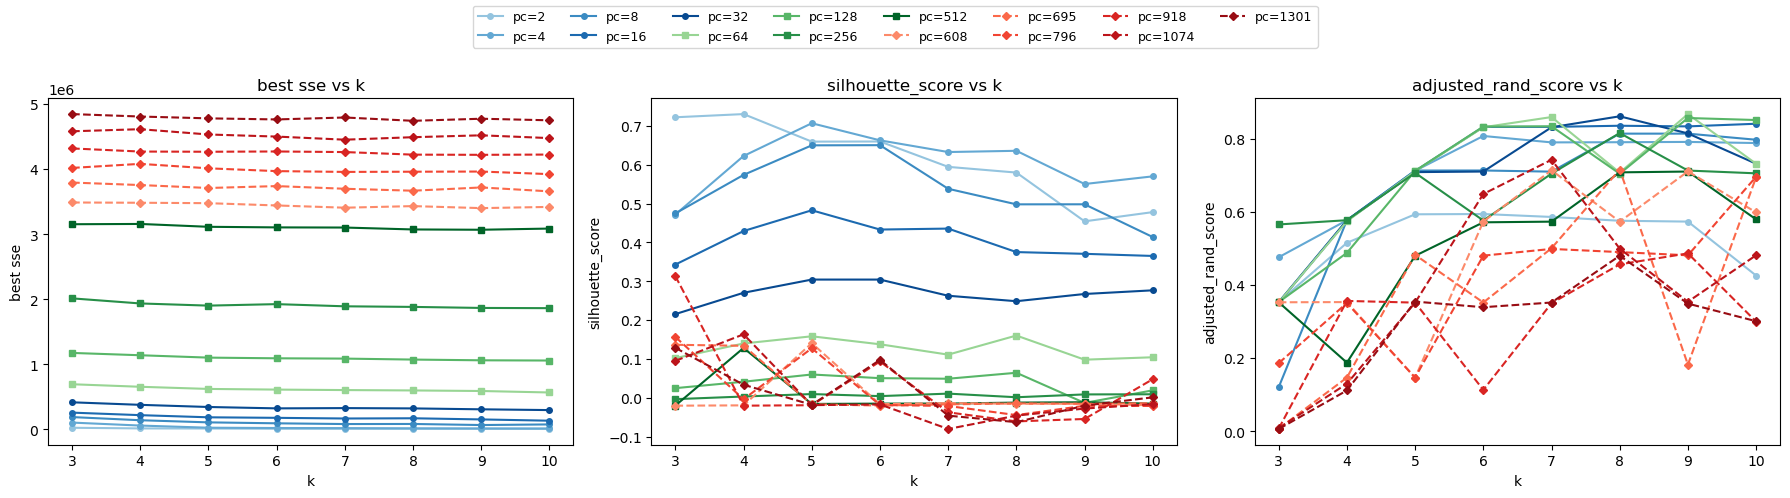

In [111]:
plot_metrics_all_pc(result_df)

## Smaller PC range

In [121]:
smaller_pc_range = [2, 4, 6, 8, 10, 15]
k_range = range(3, 11)

smaller_result_df = search_best_pc_k(
    df_pc=X_pca,
    true_labels=true_labels,
    pc_range=smaller_pc_range,
    k_range=k_range,
    random_state=0
)

In [146]:
smaller_result_df

,n_pc,k,best sse,silhouette_score,adjusted_rand_score
0,2,3,24251.036676,0.721757,0.353772
1,2,4,14176.711916,0.729973,0.515689
2,2,5,12613.815004,0.659128,0.593732
3,2,6,9334.677337,0.659475,0.594486
4,2,7,8217.810672,0.594250,0.586479
5,2,8,7907.205491,0.579548,0.576068
6,2,9,7411.562600,0.454165,0.573757
7,2,10,5601.584737,0.477860,0.426091
8,4,3,103939.218130,0.471654,0.476201
9,4,4,58106.754734,0.622186,0.577400


In [ ]:
def plot_metrics_smaller_pc(df):

    metrics = [
        "best sse",
        "silhouette_score",
        "adjusted_rand_score"
    ]

    pcs = [2, 4, 6, 8, 10, 15]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

    for i, metric in enumerate(metrics):

        ax = axes[i]

        for pc in pcs:
            subset = df[df["n_pc"] == pc]

            ax.scatter(
                subset["k"],
                subset[metric],
                label=f"pc={pc}"
            )

            ax.plot(
                subset["k"],
                subset[metric]
            )

        ax.set_xlabel("k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs k")

    axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

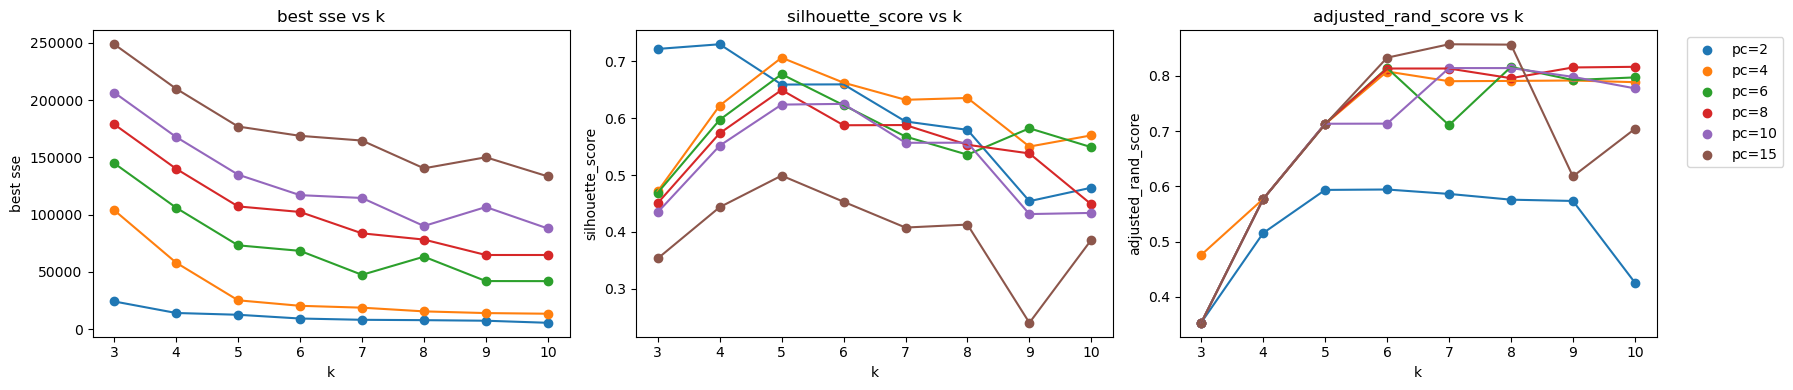

In [123]:
plot_metrics_smaller_pc(smaller_result_df)

# Searching PCs for k=8

Since 3k PBMCs used k=8, we tried to test the best PC number for k=8.

In [138]:
def search_best_pc_fixed_k(
    df_pc,
    true_labels,
    pc_range,
    k=8,
    random_state=0,
    n_trials=10
):
    results = []

    np.random.seed(random_state)

    for n_pc in pc_range:

        pc_cols = [f"PC{i}" for i in range(1, n_pc + 1)]
        X = df_pc[pc_cols].values

        if k >= len(X):
            continue

        best_sse = np.inf
        best_clusters = None

        for trial in range(n_trials):

            idx = np.random.choice(len(X), size=k, replace=False)
            random_means = X[idx]

            new_clusters, new_means, iter_objs = KMeansClustering(
                X,
                random_means
            )

            final_sse = iter_objs[-1]

            if final_sse < best_sse:
                best_sse = final_sse
                best_clusters = new_clusters

        scores = evaluate_clustering(X, best_clusters, true_labels)

        results.append({
            "n_pc": n_pc,
            "k": k,
            "best sse": best_sse,
            "silhouette_score": scores["silhouette_score"],
            "adjusted_rand_score": scores["adjusted_rand_score"]
        })

    return pd.DataFrame(results)

In [139]:
smaller_pc_range = [2, 4, 6, 8, 10, 15]

fixed_k_result_df = search_best_pc_fixed_k(
    df_pc=X_pca,
    true_labels=true_labels,
    pc_range=smaller_pc_range,
    random_state=0
)

In [140]:
fixed_k_result_df

,n_pc,k,best sse,silhouette_score,adjusted_rand_score
0,2,8,7720.011306,0.468534,0.584667
1,4,8,15674.177853,0.579559,0.810632
2,6,8,63358.460108,0.537384,0.808106
3,8,8,76462.797555,0.551980,0.795401
4,10,8,102766.666843,0.556609,0.814195
5,15,8,146657.645616,0.415488,0.819364


In [159]:
def plot_metrics_vs_pc(df):

    metrics = [
        "best sse",
        "silhouette_score",
        "adjusted_rand_score"
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

    for i, metric in enumerate(metrics):

        ax = axes[i]

        ax.scatter(
            df["n_pc"],
            df[metric]
        )

        ax.plot(
            df["n_pc"],
            df[metric]
        )

        ax.set_xticks([2, 4, 6, 8, 10, 15])
        ax.set_xlabel("Number of PCs")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs n_pc")

    plt.tight_layout()
    plt.show()

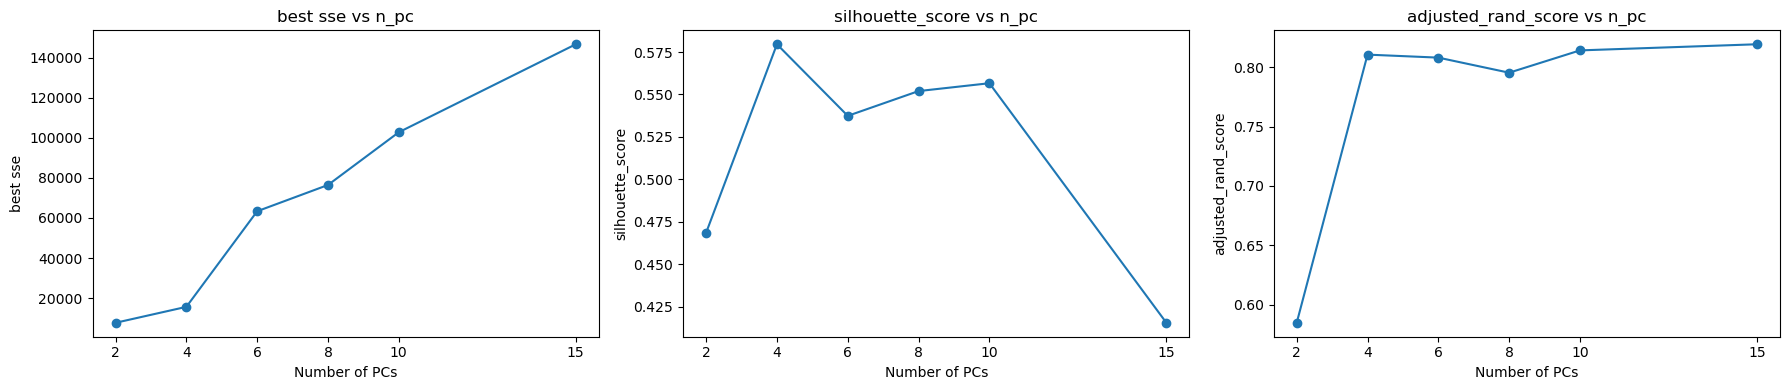

In [160]:
plot_metrics_vs_pc(fixed_k_result_df)

# Clustering 
(PC=2, K=4) from silhouette_score
(PC=7, K=15) from adjusted_rand_score

In [ ]:
def run_kmeans_and_plot_on_umap(
    pca_df,
    X_umap,
    n_pc,
    k,
    true_labels=None,
    random_state=0
):
    # --- run kmeans in PCA space --- #
    pc_cols = [f"PC{i}" for i in range(1, n_pc + 1)]
    X_pca = pca_df[pc_cols].to_numpy()

    rng = np.random.default_rng(random_state)
    init_idx = rng.choice(X_pca.shape[0], size=k, replace=False)
    init_means = X_pca[init_idx]

    clusters, means, iter_objs = KMeansClustering(X_pca, init_means)

    sil = silhouette_score(X_pca, clusters)
    ari = adjusted_rand_score(true_labels, clusters)

    # --- plotting --- #
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------- Ground truth -------- #
    ax = axes[0]

    categories = np.unique(true_labels)
    colors_true = plt.cm.tab20(np.linspace(0, 1, len(categories)))

    for i, cat in enumerate(categories):
        mask = true_labels == cat

        ax.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=[colors_true[i]],
            label=str(cat),
            s=5,
            alpha=0.7
        )

    ax.set_title("Ground Truth")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(markerscale=3, fontsize=6)


    # -------- KMeans result -------- #
    ax = axes[1]

    colors_cluster = plt.cm.tab20(np.linspace(0, 1, k))

    for cluster_id in range(k):
        mask = clusters == cluster_id

        ax.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=[colors_cluster[cluster_id]],
            label=f"Cluster {cluster_id+1}",
            s=5,
            alpha=0.7
        )

    ax.set_title(
        f"KMeans result\nPC={n_pc}, K={k}\n"
        f"ARI={ari:.3f}, Sil={sil:.3f}"
    )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    ax.legend(markerscale=3, fontsize=6)

    plt.tight_layout()
    plt.show()

    return clusters, means, iter_objs, ari, sil

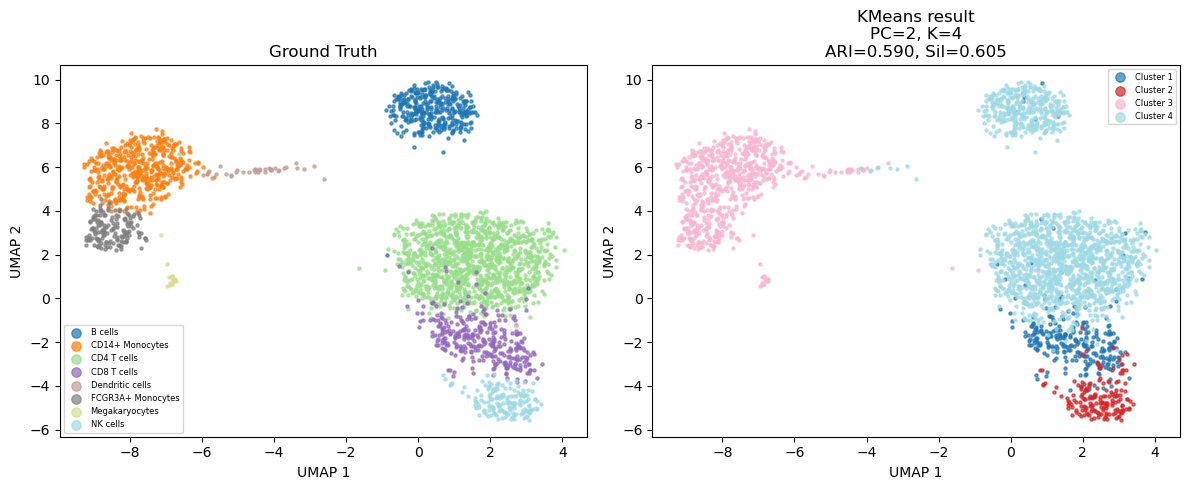

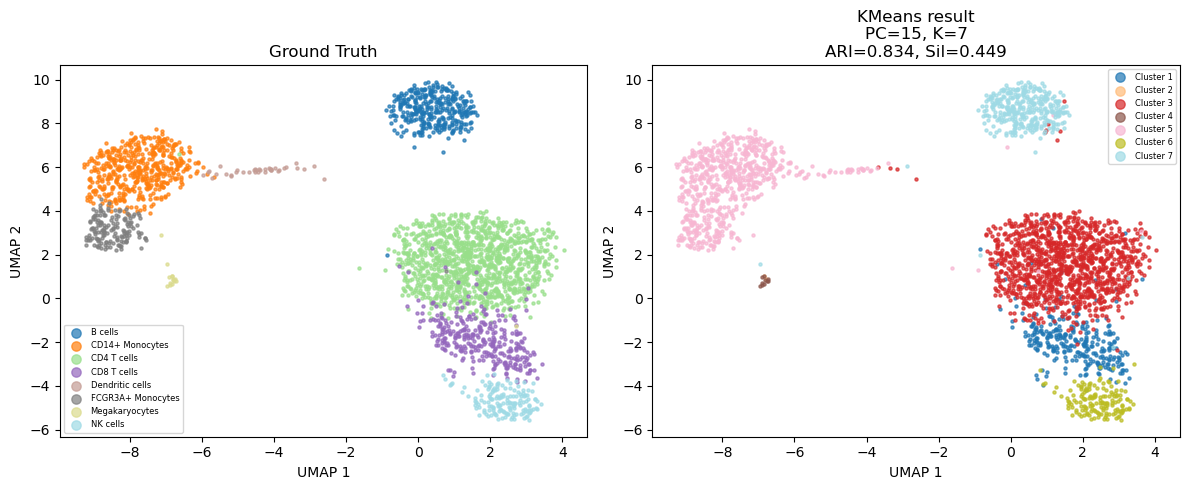

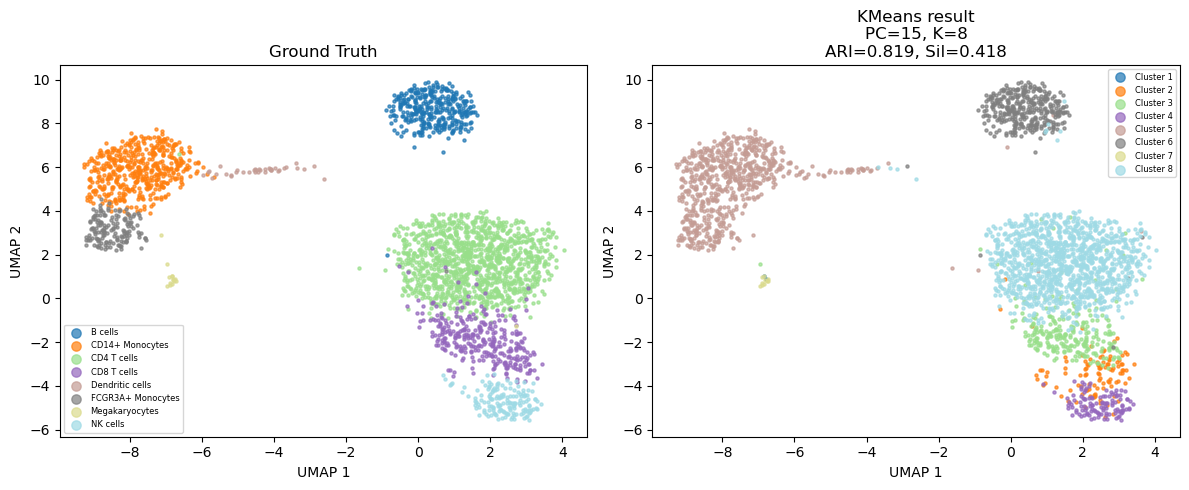

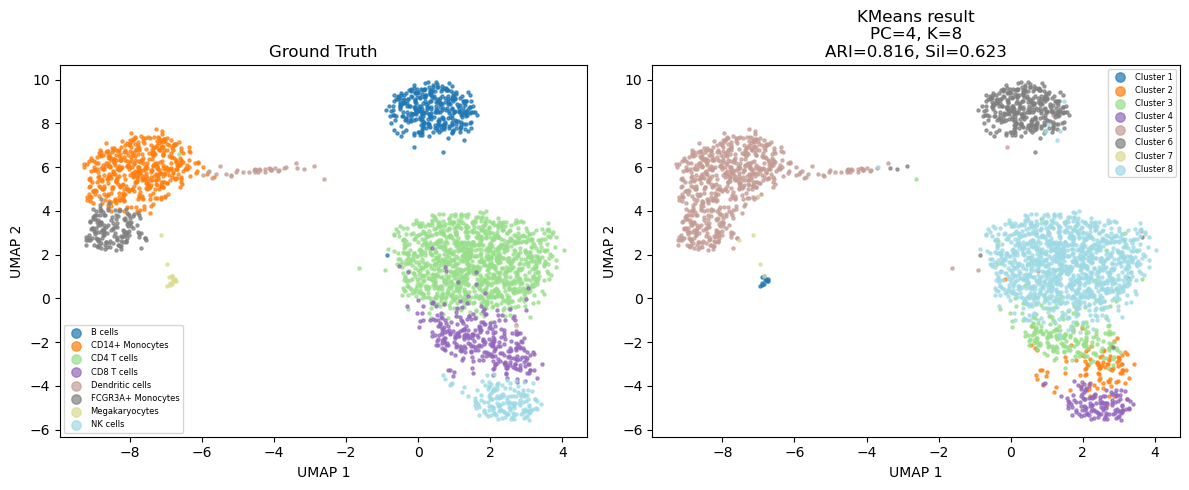

In [156]:
X_umap = adata.obsm["X_umap"]

clusters_4_2, means4_2, objs_4_2, ari_4_2, sil_4_2 = run_kmeans_and_plot_on_umap(
    pca_df=X_pca,
    X_umap=X_umap,
    n_pc=2,
    k=4,
    true_labels=true_labels,
    random_state=0
)

clusters_7_15, means_7_15, objs_7_15, ari_7_15, sil_7_15 = run_kmeans_and_plot_on_umap(
    pca_df=X_pca,
    X_umap=X_umap,
    n_pc=15,
    k=7,
    true_labels=true_labels,
    random_state=0
)

clusters_8_15, means_8_15, objs_8_15, ari_8_15, sil_8_15 = run_kmeans_and_plot_on_umap(
    pca_df=X_pca,
    X_umap=X_umap,
    n_pc=15,
    k=8,
    true_labels=true_labels,
    random_state=0
)

clusters_8_4, means_8_4, objs_8_4, ari_8_4, sil_8_4 = run_kmeans_and_plot_on_umap(
    pca_df=X_pca,
    X_umap=X_umap,
    n_pc=4,
    k=8,
    true_labels=true_labels,
    random_state=0
)